# Experiment: Stocker 2003 Extended Sea-Ice Seesaw Demo

This notebook demonstrates the extended 4-ODE Stocker-style model in PaleoBeasts.

States:
- `T_R`: ocean interior reservoir temperature
- `T_S`: Southern Ocean sea-ice zone temperature
- `A`: sea-ice area fraction
- `T_ANT`: Antarctic surface temperature

Diagnostic forcing:
- `T_N(t)`: prescribed North Atlantic/Greenland forcing


## Equations and Parameters

The model integrates:

$$	au_R \dot{T}_R = -(T_R - T_N) + \epsilon_R$$
$$	au_S \dot{T}_S = \kappa(T_R - T_S) - \lambda_S(T_S - T_{S,0}) + lpha(1-A) + \epsilon_S$$
$$	au_A \dot{A} = -eta(T_S - T_{S,0}) - \gamma A(1-A)(T_S - T_c) + \epsilon_A$$
$$	au_{ANT} \dot{T}_{ANT} = \delta(T_S - T_{ANT}) + \eta(1-A) + \epsilon_{ANT}$$

Notes:
- `A` is constrained to `[0, 1]` by model safeguards.
- This v1 uses linear eddy coupling (`\kappa(T_R-T_S)`) and nonlinear sea-ice term.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import paleobeasts as pb
from paleobeasts.signal_models import Stocker2003ExtendedSeaIceSeesaw

In [2]:
BASE_PARAMS = {
    'tau_R': 300.0,
    'tau_S': 1200.0,
    'tau_A': 100.0,
    'tau_ANT': 20.0,
    'kappa': 1.0,
    'lambda_S': 0.1,
    'alpha': 0.6,
    'beta': 0.05,
    'gamma': 5.0,
    'delta': 1.0,
    'eta': 0.2,
    'T_S0': 0.0,
    'T_c': 0.15,
    'epsilon_R': 0.0,
    'epsilon_S': 0.0,
    'epsilon_A': 0.0,
    'epsilon_ANT': 0.0,
}

def integrate_model(time, north, y0, params=None, dt=1.0):
    p = dict(BASE_PARAMS)
    if params:
        p.update(params)
    forcing = pb.Forcing(data=np.asarray(north, dtype=float), time=np.asarray(time, dtype=float), interpolation='linear')
    model = Stocker2003ExtendedSeaIceSeesaw(forcing=forcing, parameter_contract='strict', **p)
    model.integrate(
        t_span=(float(time[0]), float(time[-1])),
        y0=[float(v) for v in y0],
        method='euler',
        kwargs={'dt': float(dt)},
    )
    return model

## Baseline: Fixed North Forcing

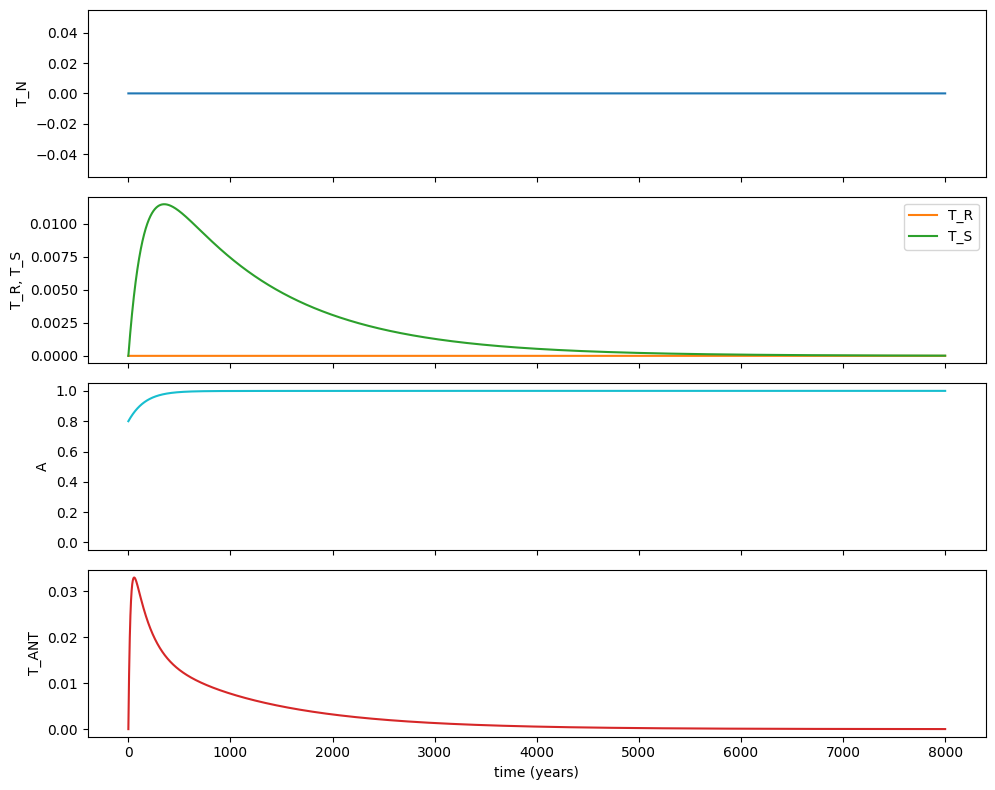

In [3]:
time = np.arange(0.0, 8000.0 + 1e-12, 1.0)
north_fixed = np.zeros_like(time)

baseline = integrate_model(time=time, north=north_fixed, y0=[0.0, 0.0, 0.8, 0.0])

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax[0].plot(baseline.time, baseline.diagnostic_variables['T_N'], color='tab:blue')
ax[0].set_ylabel('T_N')
ax[1].plot(baseline.time, baseline.state_variables['T_R'], color='tab:orange', label='T_R')
ax[1].plot(baseline.time, baseline.state_variables['T_S'], color='tab:green', label='T_S')
ax[1].legend(loc='best')
ax[1].set_ylabel('T_R, T_S')
ax[2].plot(baseline.time, baseline.state_variables['A'], color='tab:cyan')
ax[2].set_ylabel('A')
ax[2].set_ylim(-0.05, 1.05)
ax[3].plot(baseline.time, baseline.state_variables['T_ANT'], color='tab:red')
ax[3].set_ylabel('T_ANT')
ax[3].set_xlabel('time (years)')
plt.tight_layout()

## DO-like Pulse in North Forcing

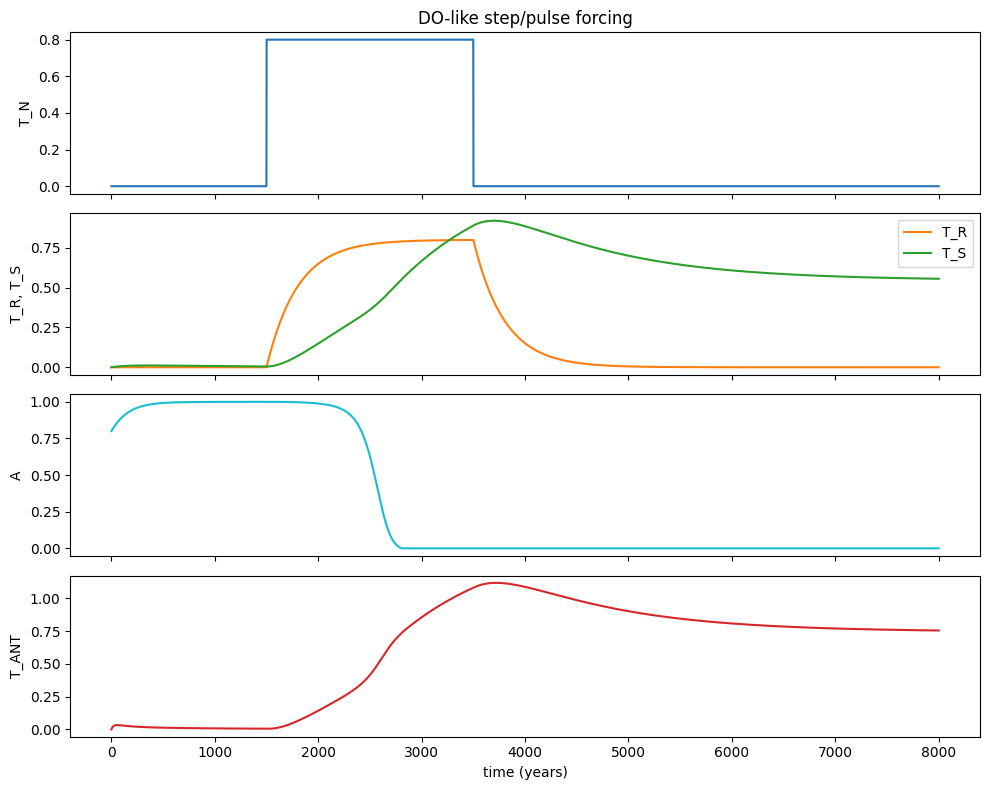

In [4]:
north_pulse = np.zeros_like(time)
north_pulse[(time >= 1500.0) & (time < 3500.0)] = 0.8

pulse = integrate_model(time=time, north=north_pulse, y0=[0.0, 0.0, 0.8, 0.0])

fig, ax = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax[0].plot(pulse.time, pulse.diagnostic_variables['T_N'], color='tab:blue')
ax[0].set_ylabel('T_N')
ax[0].set_title('DO-like step/pulse forcing')
ax[1].plot(pulse.time, pulse.state_variables['T_R'], color='tab:orange', label='T_R')
ax[1].plot(pulse.time, pulse.state_variables['T_S'], color='tab:green', label='T_S')
ax[1].legend(loc='best')
ax[1].set_ylabel('T_R, T_S')
ax[2].plot(pulse.time, pulse.state_variables['A'], color='tab:cyan')
ax[2].set_ylabel('A')
ax[2].set_ylim(-0.05, 1.05)
ax[3].plot(pulse.time, pulse.state_variables['T_ANT'], color='tab:red')
ax[3].set_ylabel('T_ANT')
ax[3].set_xlabel('time (years)')
plt.tight_layout()

## Bistability/Hysteresis Sanity: Dual Initial Ice States

Final A (low-ice initial):  0.000000
Final A (high-ice initial): 1.000000


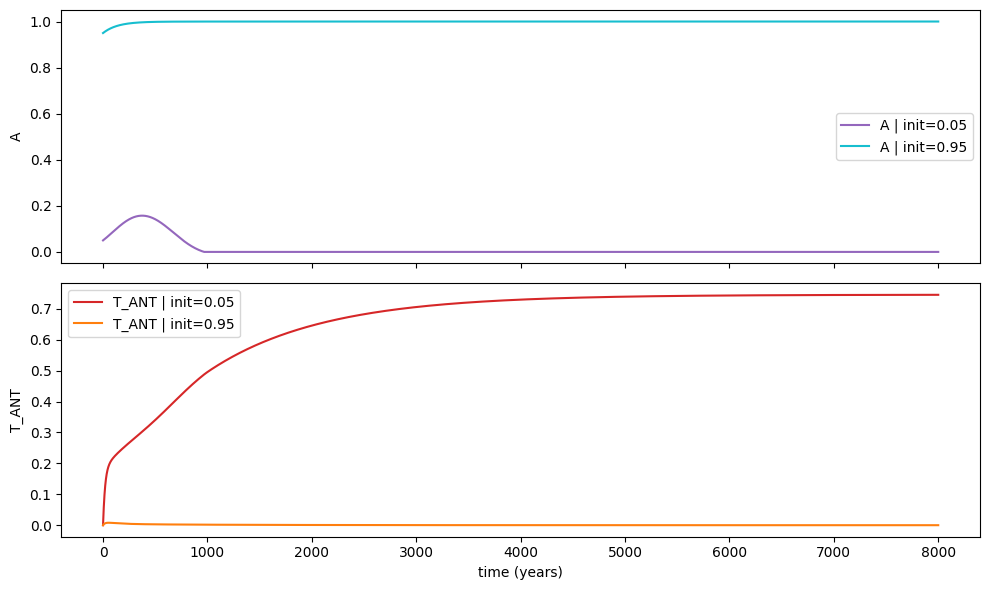

In [5]:
north_mid = np.zeros_like(time)

low_ice_init = integrate_model(time=time, north=north_mid, y0=[0.0, 0.0, 0.05, 0.0])
high_ice_init = integrate_model(time=time, north=north_mid, y0=[0.0, 0.0, 0.95, 0.0])

A_low_final = float(low_ice_init.state_variables['A'][-1])
A_high_final = float(high_ice_init.state_variables['A'][-1])
print(f'Final A (low-ice initial):  {A_low_final:.6f}')
print(f'Final A (high-ice initial): {A_high_final:.6f}')

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(low_ice_init.time, low_ice_init.state_variables['A'], label='A | init=0.05', color='tab:purple')
ax[0].plot(high_ice_init.time, high_ice_init.state_variables['A'], label='A | init=0.95', color='tab:cyan')
ax[0].set_ylabel('A')
ax[0].set_ylim(-0.05, 1.05)
ax[0].legend(loc='best')
ax[1].plot(low_ice_init.time, low_ice_init.state_variables['T_ANT'], label='T_ANT | init=0.05', color='tab:red')
ax[1].plot(high_ice_init.time, high_ice_init.state_variables['T_ANT'], label='T_ANT | init=0.95', color='tab:orange')
ax[1].set_ylabel('T_ANT')
ax[1].set_xlabel('time (years)')
ax[1].legend(loc='best')
plt.tight_layout()

## Timescale Sensitivity (tau_R, tau_S, tau_A)

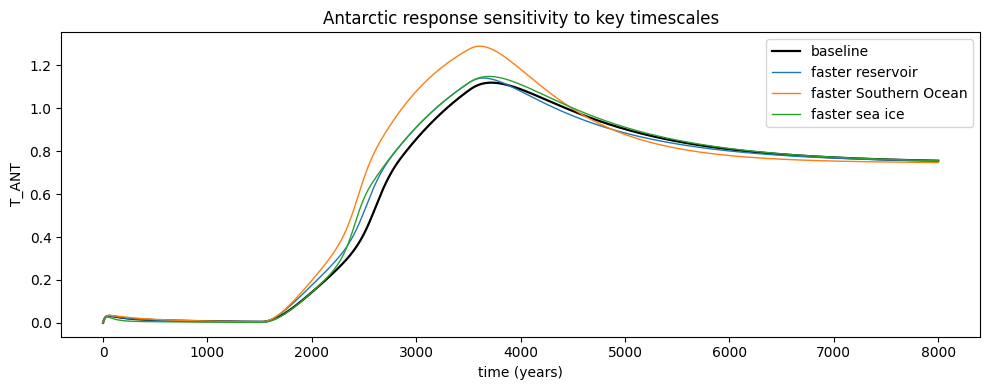

In [6]:
cases = [
    ('faster reservoir', {'tau_R': 200.0}),
    ('faster Southern Ocean', {'tau_S': 800.0}),
    ('faster sea ice', {'tau_A': 50.0}),
]

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(pulse.time, pulse.state_variables['T_ANT'], color='k', lw=1.6, label='baseline')
for label, overrides in cases:
    m = integrate_model(time=time, north=north_pulse, y0=[0.0, 0.0, 0.8, 0.0], params=overrides)
    ax.plot(m.time, m.state_variables['T_ANT'], lw=1.0, label=label)
ax.set_xlabel('time (years)')
ax.set_ylabel('T_ANT')
ax.set_title('Antarctic response sensitivity to key timescales')
ax.legend(loc='best')
plt.tight_layout()

## Notes

- This notebook demonstrates minimal-process behavior, not full paper calibration.
- The sea-ice nonlinearity is phenomenological and intended for exploratory synthetic experiments.
- Next extension: add nonlinear eddy transfer function `f(T_R-T_S)` as an optional parameterized closure.
